In [27]:
import pandas as pd
import numpy as np 
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dropout,
    Flatten,
    Dense
)

In [13]:
df = pd.read_csv("fashion-mnist_test.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
# 1
X = df.drop('label', axis=1)

# Normalize pixel values to range [0, 1]
X = X / 255.0

# Convert to NumPy arrays (optional)
X = np.array(X)
y = np.array(y)

# Check shape
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Print sample normalized values
print("\nFirst 10 normalized pixel values:")
print(X[0][:10])

Shape of X: (10000, 784)
Shape of y: (10000,)

First 10 normalized pixel values:
[0.         0.         0.         0.         0.         0.
 0.         0.03529412 0.03137255 0.        ]


In [20]:
# 2 
X = df.drop("label", axis=1).values
y = df["label"].values
X = X / 255.0
y = to_categorical(y, num_classes=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
model = Sequential()

# First Dense Layer
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Second Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
history = model.fit( X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7066 - loss: 0.8384 - val_accuracy: 0.7981 - val_loss: 0.5984
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8133 - loss: 0.5302 - val_accuracy: 0.8238 - val_loss: 0.5239
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.4808 - val_accuracy: 0.8469 - val_loss: 0.4636
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8500 - loss: 0.4215 - val_accuracy: 0.8569 - val_loss: 0.4420
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8586 - loss: 0.3909 - val_accuracy: 0.8338 - val_loss: 0.4875
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8692 - loss: 0.3658 - val_accuracy: 0.8494 - val_loss: 0.4385
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8759 - loss: 0.3397 - val_accuracy: 0.8562 - val_loss: 0.4379
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8830 - loss: 0.3277 - val_accuracy: 0.

In [25]:
loss, accuracy = model.evaluate(X_test, y_test)
print("\nTest Accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8435 - loss: 0.4533  

Test Accuracy: 0.843500018119812


In [ ]:
# 3 
import pandas as pd
import numpy as np
import tensorflow as tf





X = df.drop("label", axis=1).values
y = df["label"].values


X = X / 255.0



X = X.reshape(-1, 28, 28, 1)
y = to_categorical(y, 10)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



model = Sequential()


model.add(
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)


model.add(MaxPooling2D(pool_size=(2,2)))


model.add(Dropout(0.25))


model.add(
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu'
    )
)

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Dropout Layer
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))



model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

Epoch 1/10


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6108 - loss: 1.0848 - val_accuracy: 0.7650 - val_loss: 0.6293
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7458 - loss: 0.6851 - val_accuracy: 0.8106 - val_loss: 0.5217
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7830 - loss: 0.5835 - val_accuracy: 0.8275 - val_loss: 0.4877
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8020 - loss: 0.5345 - val_accuracy: 0.8388 - val_loss: 0.4564
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8109 - loss: 0.4984 - val_accuracy: 0.8456 - val_loss: 0.4231
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8230 - loss: 0.4700 - val_accuracy: 0.8506 - val_loss: 0.4103
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8342 - loss: 0.4485 - val_accuracy: 0.8612 - val_loss: 0.3856
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8380 - loss: 0.4260 - val_accuracy: 0.8644 - val_

Epoch 1/10


c:\Users\skadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6061 - loss: 1.1022 - val_accuracy: 0.7619 - val_loss: 0.6278
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7433 - loss: 0.6838 - val_accuracy: 0.7956 - val_loss: 0.5488
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7636 - loss: 0.6087 - val_accuracy: 0.8181 - val_loss: 0.5066
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7898 - loss: 0.5574 - val_accuracy: 0.8350 - val_loss: 0.4726
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8064 - loss: 0.5211 - val_accuracy: 0.8413 - val_loss: 0.4548
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8180 - loss: 0.4889 - val_accuracy: 0.8494 - val_loss: 0.4201
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8239 - loss: 0.4619 - val_accuracy: 0.8569 - val_loss: 0.4190
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8375 - loss: 0.4409 - val_accuracy: 0.8569 - val_

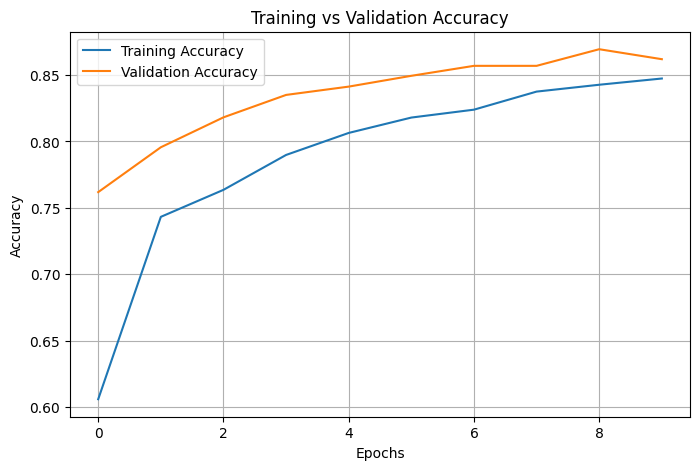

In [ ]:
# 4 
import matplotlib.pyplot as plt



X = df.drop("label", axis=1).values
y = df["label"].values



X = X / 255.0



X = X.reshape(-1, 28, 28, 1)



y = to_categorical(y, 10)



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)



model = Sequential()

# Convolution Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

# Pooling Layer 1
model.add(MaxPooling2D((2,2)))

# Dropout Layer
model.add(Dropout(0.25))

# Convolution Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Pooling Layer 2
model.add(MaxPooling2D((2,2)))

# Dropout Layer
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))


model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)


plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()